In [4]:
import sys
print(sys.executable)
print(sys.version)
!{sys.executable} -m pip install opencv-python torch pandas


c:\Users\Admin\AppData\Local\Programs\Python\Python312\python.exe
3.12.0 (tags/v3.12.0:0fb18b0, Oct  2 2023, 13:03:39) [MSC v.1935 64 bit (AMD64)]

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 24.3.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip



  Using cached opencv_python-4.13.0.90-cp37-abi3-win_amd64.whl.metadata (20 kB)
  Using cached numpy-2.4.1-cp312-cp312-win_amd64.whl.metadata (6.6 kB)
Using cached opencv_python-4.13.0.90-cp37-abi3-win_amd64.whl (40.2 MB)
Using cached numpy-2.4.1-cp312-cp312-win_amd64.whl (12.3 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.3
    Uninstalling numpy-1.26.3:
      Successfully uninstalled numpy-1.26.3


In [1]:
import os
import cv2
import torch
import pandas as pd
import numpy as np
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

In [5]:
# Dataset PyTorch pour eyetracking

class EyeTrackingDataset(Dataset):
    def __init__(self, csv_file, img_dir, img_size=(224,224), transform=None):
        self.df = pd.read_csv(csv_file)
        self.img_dir = img_dir
        self.img_size = img_size
        self.transform = transform

        # filtrer les lignes où l'image existe et est valide
        valid_indices = []
        for idx, row in self.df.iterrows():
            fid = int(row['frame_id'])
            img_path = os.path.join(img_dir, f"frame_{fid:04d}.png")
            if os.path.exists(img_path):
                img = cv2.imread(img_path)
                if img is not None and len(img.shape) == 3 and img.shape[0] > 0 and img.shape[1] > 0:
                    valid_indices.append(idx)
        self.df = self.df.iloc[valid_indices].reset_index(drop=True)

        # créer mapping frame_id -> image path
        self.img_paths = [os.path.join(img_dir, f"frame_{int(fid):04d}.png") 
                          for fid in self.df['frame_id']]

        # extraire les coordonnées
        self.coords = self.df[['x','y']].values.astype(np.float32)

        # Calculer les maxima pour normalisation
        self.max_x = 1272 #np.max(self.coords[:, 0])
        self.max_y = 712 #np.max(self.coords[:, 1])

        # Normaliser toutes les coordonnées
        self.coords[:, 0] /= self.max_x
        self.coords[:, 1] /= self.max_y
        

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.img_paths[idx]
        img = cv2.imread(img_path)
        if img.ndim == 2:
            img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
        elif img.shape[2] == 1:
            img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
        else:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # resize
        img = cv2.resize(img, self.img_size)

        # coordonnées déjà normalisées
        x, y = self.coords[idx]
        label = torch.tensor([x, abs(y)], dtype=torch.float32)

        # transform PyTorch (ToTensor + normalisation)
        if self.transform:
            img = self.transform(img)
        else:
            # default transform
            img = transforms.ToTensor()(img)
            img = transforms.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5])(img)

        return img, label

In [6]:
csv_file = "C:\\Users\\Admin\\Documents\\5A\\a_learning\\AL_project\\active_learning\\data\\coords_20260121_082431.csv"

# Créer les datasets séparés
train_dataset = EyeTrackingDataset(csv_file, "data/dataset/train")
dev_dataset = EyeTrackingDataset(csv_file, "data/dataset/dev")
test_dataset = EyeTrackingDataset(csv_file, "data/dataset/test")

print(f"Train size: {len(train_dataset)}")
print(f"Dev size: {len(dev_dataset)}")
print(f"Test size: {len(test_dataset)}")

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
dev_loader = DataLoader(dev_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Vérification rapide
imgs, labels = next(iter(train_loader))
print(imgs.shape, labels.shape)  # imgs: [B,3,H,W], labels: [B,2]

Train size: 1248
Dev size: 269
Test size: 268
torch.Size([32, 3, 224, 224]) torch.Size([32, 2])


In [7]:
print(train_dataset.max_x, train_dataset.max_y)
print(dev_dataset.max_x, dev_dataset.max_y)
print(test_dataset.max_x, test_dataset.max_y)

1272 712
1272 712
1272 712


In [36]:
# Définition du modèle CNN pour prédiction du regard
import torch.nn as nn

class GazeNet(nn.Module):
    def __init__(self):
        super(GazeNet, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(4, 4)
        self.fc1 = nn.Linear(6272, 256)
        self.fc2 = nn.Linear(256, 2)
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = x.view(x.shape[0], -1)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        x = self.sigmoid(x)
        return x

model = GazeNet()
print("number of parameters:", sum(p.numel() for p in model.parameters() if p.requires_grad))


number of parameters: 1611490


In [37]:
# Entraînement

import torch.optim as optim

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

num_epochs = 20  

# Pour stocker les pertes et accuracies
train_losses = []
val_losses = []
train_maes = []
val_maes = []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    running_mae = 0.0
    count = 0
    for imgs, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        mae = torch.mean(torch.abs(outputs - labels)).item()
        running_mae += mae
        count += 1
    
    train_loss = running_loss / count
    train_mae = running_mae / count
    train_losses.append(train_loss)
    train_maes.append(train_mae)
    
    # Validation
    model.eval()
    val_loss = 0.0
    val_mae = 0.0
    count = 0
    with torch.no_grad():
        for imgs, labels in dev_loader:
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            mae = torch.mean(torch.abs(outputs - labels)).item()
            val_mae += mae
            count += 1
    
    val_loss = val_loss / count
    val_mae = val_mae / count
    val_losses.append(val_loss)
    val_maes.append(val_mae)
    
    print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.4f}, Train MAE: {train_mae:.4f}, Val Loss: {val_loss:.4f}, Val MAE: {val_mae:.4f}")

print("Entraînement terminé.")

Epoch 1/20, Train Loss: 0.0525, Train MAE: 0.1861, Val Loss: 0.0330, Val MAE: 0.1454
Epoch 2/20, Train Loss: 0.0344, Train MAE: 0.1322, Val Loss: 0.0195, Val MAE: 0.1130
Epoch 3/20, Train Loss: 0.0256, Train MAE: 0.1067, Val Loss: 0.0118, Val MAE: 0.0856
Epoch 4/20, Train Loss: 0.0199, Train MAE: 0.0939, Val Loss: 0.0113, Val MAE: 0.0857
Epoch 5/20, Train Loss: 0.0156, Train MAE: 0.0828, Val Loss: 0.0113, Val MAE: 0.0868
Epoch 6/20, Train Loss: 0.0145, Train MAE: 0.0792, Val Loss: 0.0092, Val MAE: 0.0704
Epoch 7/20, Train Loss: 0.0127, Train MAE: 0.0754, Val Loss: 0.0148, Val MAE: 0.0861
Epoch 8/20, Train Loss: 0.0124, Train MAE: 0.0741, Val Loss: 0.0117, Val MAE: 0.0757
Epoch 9/20, Train Loss: 0.0099, Train MAE: 0.0653, Val Loss: 0.0198, Val MAE: 0.0987
Epoch 10/20, Train Loss: 0.0086, Train MAE: 0.0612, Val Loss: 0.0171, Val MAE: 0.0893
Epoch 11/20, Train Loss: 0.0078, Train MAE: 0.0576, Val Loss: 0.0155, Val MAE: 0.0841
Epoch 12/20, Train Loss: 0.0073, Train MAE: 0.0555, Val Loss: 0

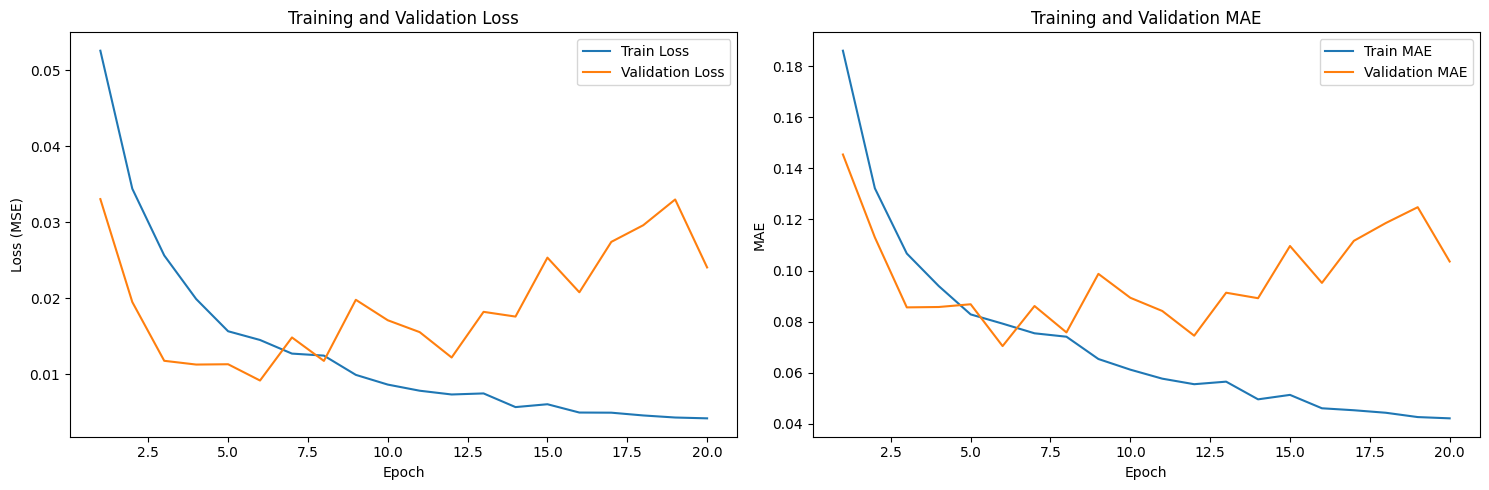

In [38]:
# Affichage des courbes de perte et MAE
import matplotlib.pyplot as plt

epochs = range(1, num_epochs + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Courbes de Loss
ax1.plot(epochs, train_losses, label='Train Loss')
ax1.plot(epochs, val_losses, label='Validation Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss (MSE)')
ax1.set_title('Training and Validation Loss')
ax1.legend()

# Courbes de MAE
ax2.plot(epochs, train_maes, label='Train MAE')
ax2.plot(epochs, val_maes, label='Validation MAE')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('MAE')
ax2.set_title('Training and Validation MAE')
ax2.legend()

plt.tight_layout()
plt.show()

In [39]:
# Évaluation sur le test set

model.eval()
test_loss = 0.0
all_preds = []
all_labels = []
with torch.no_grad():
    for imgs, labels in test_loader:
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        test_loss += loss.item()
        all_preds.append(outputs.cpu())
        all_labels.append(labels.cpu())

all_preds = torch.cat(all_preds)
all_labels = torch.cat(all_labels)

# Calcul des métriques
mae = torch.mean(torch.abs(all_preds - all_labels)).item()
rmse = torch.sqrt(torch.mean((all_preds - all_labels)**2)).item()

# Accuracy: pourcentage de prédictions avec distance euclidienne < 0.1
distances = torch.sqrt(torch.sum((all_preds - all_labels)**2, dim=1))
accuracy = (distances < 0.1).float().mean().item() * 100

print(f"Test Loss (MSE): {test_loss/len(test_loader):.4f}")
print(f"Test MAE: {mae:.4f}")
print(f"Test RMSE: {rmse:.4f}")
print(f"Test Accuracy (dist < 0.1): {accuracy:.2f}%")

# Sauvegarder le modèle
torch.save(model.state_dict(), 'gaze_model.pth')
print("Modèle sauvegardé.")

Test Loss (MSE): 0.0326
Test MAE: 0.1267
Test RMSE: 0.1785
Test Accuracy (dist < 0.1): 23.51%
Modèle sauvegardé.


In [34]:
# Comparaison avec un modèle aléatoire (non entraîné)

random_model = GazeNet()  

random_model.eval()
random_test_loss = 0.0
random_preds = []
random_labels = []
with torch.no_grad():
    for imgs, labels in test_loader:
        outputs = random_model(imgs)
        loss = criterion(outputs, labels)
        random_test_loss += loss.item()
        random_preds.append(outputs.cpu())
        random_labels.append(labels.cpu())
        print(f"max outputs: {outputs[0]}")
        print(f"min label: {labels[0]}")

random_preds = torch.cat(random_preds)
random_labels = torch.cat(random_labels)

random_mae = torch.mean(torch.abs(random_preds - random_labels)).item()
random_rmse = torch.sqrt(torch.mean((random_preds - random_labels)**2)).item()

# Accuracy pour random
random_distances = torch.sqrt(torch.sum((random_preds - random_labels)**2, dim=1))
random_accuracy = (random_distances < 0.1).float().mean().item() * 100

print(f"Test Loss du modèle aléatoire (MSE): {random_test_loss/len(test_loader):.4f}")
print(f"Test MAE du modèle aléatoire: {random_mae:.4f}")


torch.Size([32, 3, 224, 224])
max outputs: tensor([0.4992, 0.5020])
min label: tensor([0.4748, 0.9157])
torch.Size([32, 3, 224, 224])
max outputs: tensor([0.4974, 0.5004])
min label: tensor([0.4937, 0.0169])
torch.Size([32, 3, 224, 224])
max outputs: tensor([0.4968, 0.5013])
min label: tensor([0.5126, 0.8596])
torch.Size([32, 3, 224, 224])
max outputs: tensor([0.4977, 0.5015])
min label: tensor([0.5314, 0.2416])
torch.Size([32, 3, 224, 224])
max outputs: tensor([0.4972, 0.5009])
min label: tensor([0.5495, 0.6348])
torch.Size([32, 3, 224, 224])
max outputs: tensor([0.4976, 0.5016])
min label: tensor([0.5684, 0.4663])
torch.Size([32, 3, 224, 224])
max outputs: tensor([0.4978, 0.5010])
min label: tensor([0.5873, 0.4101])
torch.Size([32, 3, 224, 224])
max outputs: tensor([0.4976, 0.5014])
min label: tensor([0.6061, 0.6910])
torch.Size([12, 3, 224, 224])
max outputs: tensor([0.4980, 0.5012])
min label: tensor([0.6250, 0.1854])
Test Loss du modèle aléatoire (MSE): 0.0433
Test MAE du modèle a

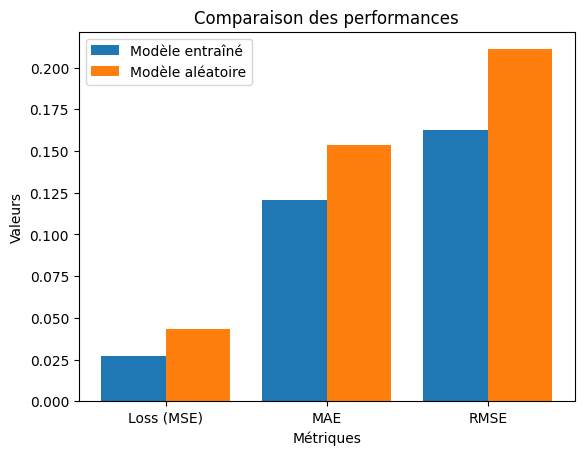

In [30]:
# Comparaison des métriques finales
import matplotlib.pyplot as plt

metrics = ['Loss (MSE)', 'MAE', 'RMSE']
trained_values = [test_loss / len(test_loader), mae, rmse]
random_values = [random_test_loss / len(test_loader), random_mae, random_rmse]

x = range(len(metrics))
plt.bar(x, trained_values, width=0.4, label='Modèle entraîné', align='center')
plt.bar([i + 0.4 for i in x], random_values, width=0.4, label='Modèle aléatoire', align='center')
plt.xlabel('Métriques')
plt.ylabel('Valeurs')
plt.title('Comparaison des performances')
plt.xticks([i + 0.2 for i in x], metrics)
plt.legend()
plt.show()